# Eigenmode

In [1]:
import sys
sys.path.append("../..")
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
import time
plt.ion()
%matplotlib inline
from cavsim2d.cavity import Cavity, Cavities, OperationPoints, EllipticalCavity
import pprint
pp = pprint.PrettyPrinter(indent=4)

In [ ]:
%%time
from cavsim2d.cavity import *
# create cavities
cavs = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')
# must first save cavities

# define geometry parameters
# midcell = np.array([42, 42, 12, 19, 35, 57.7, 103.353])
# endcell_l = np.array([40.34, 40.34, 10, 13.5, 39, 55.716, 103.353])
# endcell_r = np.array([42, 42, 9, 12.8, 39, 56.815, 103.353])
midcell = [62.22, 66.13, 30.22, 23.11, 72, 93.795, 171.20]  # <- A, B, a, b, Ri, L, Req
endcell_l = [62.58, 57.54, 17.21, 12, 80, 93.795, 171.20]
endcell_r = [62.58, 57.54, 17.21, 12, 80, 93.795, 171.20]
# create cavity
cav1 = EllipticalCavity(2, midcell, endcell_l, endcell_r, beampipe='both')
cavs.add_cavity([cav1], ['C3795'])

eigenmode_config = {
    'processes': 1,
    'rerun': True,
    'boundary_conditions': 'mm',
    # 'mesh_config': {'h': 15}
    }
# run eigenmode analysis
cavs.run_eigenmode(eigenmode_config)  #modify to delete UQ results if rerun=True is selected

CPU times: total: 5.44 s
Wall time: 4.77 s


In [3]:
cav1.plot_fields(2, 'E', 'quadrupole')

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

In [4]:
pp.pprint(cavs.eigenmode_qois)

{   'C3794': {   'Bpk [mT]': 6.40836973821177e-05,
                 'Bpk/Eacc [mT/MV/m]': 4.9347869675939355,
                 'Eacc [MV/m]': 1.2986112227933343e-05,
                 'Epk [MV/m]': 3.17437673774008e-05,
                 'Epk/Eacc []': 2.444439630601638,
                 'G [Ohm]': 270.3088333839684,
                 'GR/Q [Ohm^2]': 45789.39795124231,
                 'Hpk [A/m]': 0.05099618604984593,
                 'N Cells': 2,
                 'No of Mesh Elements': 207,
                 'Normalization Length [mm]': 187.59,
                 'Q []': 37091.65845402275,
                 'R/Q [Ohm]': 169.39660231598634,
                 'Rsh [MOhm]': 6.283200916376484,
                 'Vacc [MV]': 4.872129585676032e-06,
                 'ff [%]': 99.95954039571791,
                 'freq [MHz]': 801.7786641845569,
                 'kcc [%]': 1.4171395349825482}}


{'freq [MHz]': <Axes: label='freq [MHz]', ylabel='$f$ [MHz]'>,
 'Epk/Eacc []': <Axes: label='Epk/Eacc []', ylabel='$E_\\mathrm{pk}/E_\\mathrm{acc} ~[\\cdot]$'>,
 'Bpk/Eacc [mT/MV/m]': <Axes: label='Bpk/Eacc [mT/MV/m]', ylabel='$B_\\mathrm{pk}/E_\\mathrm{acc} ~\\mathrm{[mT/MV/m]}$'>,
 'kcc [%]': <Axes: label='kcc [%]', ylabel='$k_\\mathrm{cc}$ [%]'>,
 'R/Q [Ohm]': <Axes: label='R/Q [Ohm]', ylabel='$R/Q ~\\mathrm{[\\Omega]}$'>,
 'G [Ohm]': <Axes: label='G [Ohm]', ylabel='$G ~\\mathrm{[\\Omega]}$'>,
 'GR/Q [Ohm^2]': <Axes: label='GR/Q [Ohm^2]', ylabel='$G \\cdot R/Q \\mathrm{[\\Omega^2]}$'>}

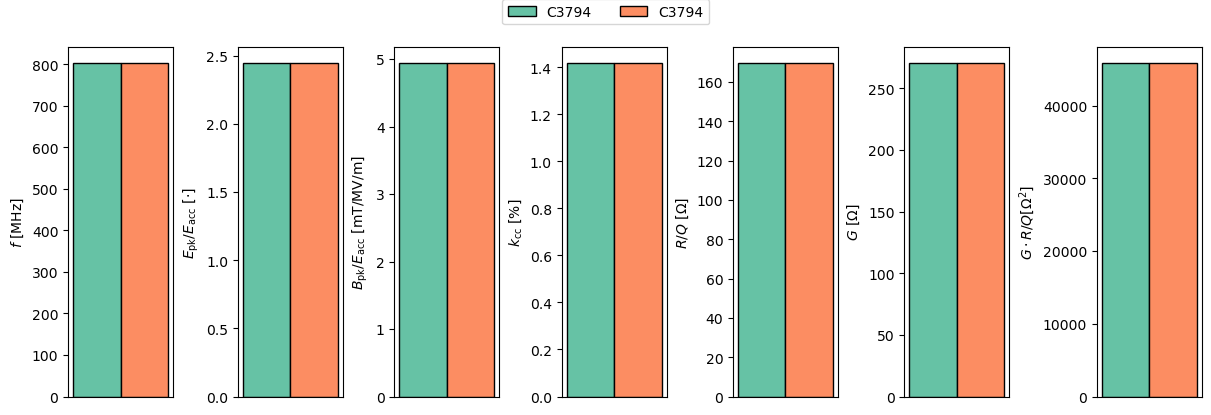

In [5]:
cavs.plot_compare_fm_bar()

# m-pole eigenmodes (dipole, quadrupole, sextupole, ...)

In [6]:
%%time
eigenmode_config = {
    'processes': 1,
    'rerun': True,
    'boundary_conditions': 'mm',
    'polarisation': ['dipole', 'quadrupole'],  # names or m numbers, e.g. [0, 1, 2]
    'n_modes': 4,  # physical modes per m-pole solve (monopole mode count is unchanged)
    }
# run eigenmode analysis for all requested polarisations on one mesh
cavs.run_eigenmode(eigenmode_config)

CPU times: total: 13.9 s
Wall time: 10.8 s


In [7]:
# QOIs of all computed dipole modes (same access pattern for 'quadrupole', 'sextupole', ...)
# pp.pprint(cav1.eigenmode.mpole_qois('dipole'))

In [8]:
# mode summary as EigenmodeResult objects (index, frequency, azimuthal mode number m)
for mode in cav1.eigenmode.mpole_modes('dipole'):
    print(mode)
for mode in cav1.eigenmode.mpole_modes('quadrupole'):
    print(mode)

EigenmodeResult(index=0, f=928.84 MHz, m=1)
EigenmodeResult(index=1, f=985.96 MHz, m=1)
EigenmodeResult(index=2, f=1056.16 MHz, m=1)
EigenmodeResult(index=3, f=1115.74 MHz, m=1)
EigenmodeResult(index=4, f=1117.39 MHz, m=1)
EigenmodeResult(index=5, f=1135.07 MHz, m=1)
EigenmodeResult(index=6, f=1228.71 MHz, m=1)
EigenmodeResult(index=7, f=1231.42 MHz, m=1)
EigenmodeResult(index=0, f=1382.26 MHz, m=2)
EigenmodeResult(index=1, f=1394.02 MHz, m=2)
EigenmodeResult(index=2, f=1469.29 MHz, m=2)
EigenmodeResult(index=3, f=1490.82 MHz, m=2)
EigenmodeResult(index=4, f=1825.93 MHz, m=2)
EigenmodeResult(index=5, f=1826.39 MHz, m=2)
EigenmodeResult(index=6, f=1863.25 MHz, m=2)
EigenmodeResult(index=7, f=1869.83 MHz, m=2)


In [9]:
# in-plane |E| envelope of the first dipole mode.
# which='Ephi' / 'H' / 'Hphi' select the azimuthal E and the H envelopes.
cav1.plot_fields(mode=1, which='E', pol='dipole')

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

# Eigenmode + UQ

In [10]:
from cavsim2d.cavity import *
# create cavities
cavs = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')

# define geometry parameters
midcell = np.array([42, 42, 12, 19, 35, 57.7, 103.353])
endcell_l = np.array([40.34, 40.34, 10, 13.5, 39, 55.716, 103.353])
endcell_r = np.array([42, 42, 9, 12.8, 39, 56.815, 103.353])
# create cavity
cav1 = EllipticalCavity(2, midcell, endcell_l, endcell_r, beampipe='both')
cavs.add_cavity([cav1], ['TESLA'])

eigenmode_config = {
    'processes': 3,
    'rerun': True,
    'boundary_conditions': 'mm',
    'uq_config': {
        'variables': ['A', 'B', 'a', 'b'],
        'objectives': ["Epk/Eacc []", "Bpk/Eacc [mT/MV/m]", "R/Q [Ohm]", "G [Ohm]"],
        'delta': [0.05, 0.05, 0.05, 0.05],
        'processes': 4,
        'distribution': 'gaussian',
        'method': ['Quadrature', 'Stroud3'],
        'cell_type': 'mid-cell',
        'cell_complexity': 'simplecell'
        }
    }
# run eigenmode analysis
cavs.run_eigenmode(eigenmode_config)  #modify to delete UQ results if rerun=True is selected

In [11]:
pp.pprint(cavs.uq_fm_results)

{   'TESLA': {   'Bpk [mT]': {   'expe': [0.00013023780338646654],
                                 'kurtosis': [2.698011439224597],
                                 'skew': [0.8128825109113342],
                                 'stdDev': [4.5297697318025703e-07]},
                 'Bpk/Eacc [mT/MV/m]': {   'expe': [4.262548804944247],
                                           'kurtosis': [2.6633365385895966],
                                           'skew': [0.7901340545028853],
                                           'stdDev': [0.014876203580311215]},
                 'Eacc [MV/m]': {   'expe': [3.0553975022645376e-05],
                                    'kurtosis': [6.202179017525091],
                                    'skew': [0.34878814981404865],
                                    'stdDev': [3.6022490571692523e-09]},
                 'Epk [MV/m]': {   'expe': [6.259065607647163e-05],
                                   'kurtosis': [3.879633591003928],
                   

{'freq [MHz]': <Axes: label='freq [MHz]', xlabel='$f$ [MHz]'>,
 'Epk/Eacc []': <Axes: label='Epk/Eacc []', xlabel='$E_\\mathrm{pk}/E_\\mathrm{acc} ~[\\cdot]$'>,
 'Bpk/Eacc [mT/MV/m]': <Axes: label='Bpk/Eacc [mT/MV/m]', xlabel='$B_\\mathrm{pk}/E_\\mathrm{acc} ~\\mathrm{[mT/MV/m]}$'>,
 'R/Q [Ohm]': <Axes: label='R/Q [Ohm]', xlabel='$R/Q ~\\mathrm{[\\Omega]}$'>}

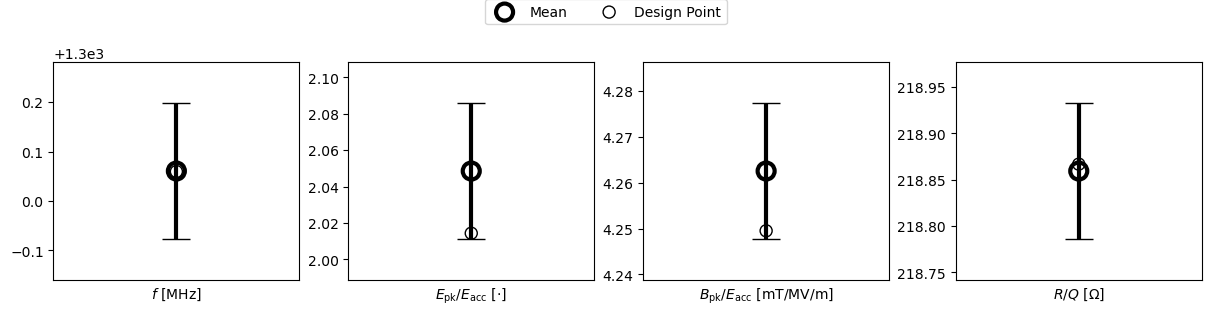

In [12]:
cavs.plot_compare_fm_scatter(uq=True)

In [15]:
# cavs.plot_uq_geometries()